# Full experiment

## Initialization

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score
import datetime as dt

# from scipy import signal
from scipy.interpolate import make_splrep
import os
from pathlib import Path
from tqdm.auto import tqdm
from pprint import pprint
import ruptures as rpt
from ruptures.metrics import precision_recall, hausdorff, randindex
from movement_primitives.dmp import DMPWithFinalVelocity

In [2]:
from segmentation_utils import (
    # extract_eef_data_from_rosbag,
    get_ground_truth_segmentation,
    # get_bagfiles_from_json,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [3]:
from LfD_Library.MP_Library import gen_traj, MP_Library
from LfD_Library.sim_metrics import *
from ElasticMaps.elmap_EM import ElmapEM

In [4]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

## Hyperparameters

In [5]:
resample_num = 2**8
print(f"Resampling to {resample_num} data points")
similarity_threshold = 0.4
lib_path = Path("lib.h5")

Resampling to 256 data points


## Data

In [6]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path(".") / "data"
assert data_path_root.exists()

In [7]:
ground_truth_segm_file = Path(".") / "segm_ground_truth.json"
assert ground_truth_segm_file.exists()

# Learn skills from subtasks (build the library)

In [8]:
def plot_xyzgrip(traj):
    with plt.style.context("ggplot_perso.mplstyle"):
        # with plt.style.context("ggplot"):
        fig, ax = plt.subplots(figsize=(8, 5))
        # cmap = mpl.colormaps.get("tab10").colors
        ax.plot(traj.timestamp, traj.x, label="x")  # , color=cmap[0])
        ax.plot(traj.timestamp, traj.y, label="y")  # , color=cmap[1])
        ax.plot(traj.timestamp, traj.z, label="z")  # , color=cmap[2])
        ax.plot(traj.timestamp, traj.gripper, label="gripper")  # , color=cmap[3])
        ax.set_xlabel("Time")
        ax.set_ylabel("End effector position")
        # ax.legend(loc="best")
        ax.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [9]:
def plot_activation_func(traj, objects, obj_labels):
    with plt.style.context("ggplot_perso.mplstyle"):
        cmap = mpl.colormaps.get("Set2").colors
        fig, ax = plt.subplots(figsize=(8, 5))
        for idx in range(objects.shape[1]):
            ax.plot(
                traj.timestamp,
                objects[:, idx],
                # label=obj_labels[idx],
                color="k",
                # linewidth=1.5,
            )
        ax.stackplot(
            traj.timestamp,
            objects.T,
            labels=obj_labels,
            alpha=0.6,
            colors=cmap,
        )
        ax.set_xlabel("Time")
        ax.set_ylabel("Activation functions")
        # ax.legend(loc="best")
        ax.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [10]:
def augment_traj_activation_functions(gt_segm_dict, traj):
    nsegments = 0
    obj_labels = []
    for segm_key, segm_val in gt_segm_dict["segments"].items():
        if isinstance(segm_val, list):
            nsegments += len(segm_val)
            for jdx, _ in enumerate(segm_val):
                obj_labels.append(f"{segm_key}-{jdx + 1}")
        elif isinstance(segm_val, dict):
            nsegments += 1
            obj_labels.append(segm_key)
        else:
            raise ValueError("Unexpected value in ground truth JSON file")

    objects = np.zeros((traj.shape[0], nsegments))

    col_i = 0
    for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
        sect_dict_current = gt_segm_dict["segments"][sect_key]
        if isinstance(sect_dict_current, list):
            for sect_j, sect_cur in enumerate(sect_dict_current):
                xs = traj.timestamp[
                    (
                        traj.timestamp
                        > pd.Timestamp(
                            dt.datetime.fromtimestamp(sect_cur["ini"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                    & (
                        traj.timestamp
                        < pd.Timestamp(
                            dt.datetime.fromtimestamp(sect_cur["end"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                ]
                print(col_i)
                objects[xs.index, col_i] = np.ones_like(xs)
                col_i += 1

        elif isinstance(sect_dict_current, dict):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_dict_current["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_dict_current["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]
            print(col_i)
            objects[xs.index, col_i] = np.ones_like(xs)
            col_i += 1
        else:
            raise ValueError("Unexpected value in ground truth JSON file")

    plot_activation_func(traj=traj, objects=objects, obj_labels=obj_labels)

    for idx in range(objects.shape[1]):
        traj[obj_labels[idx]] = objects[:, idx]

    return traj, nsegments

In [11]:
def plot_segments(traj, gt_segm_dict, nsegments):
    df_labels = list(traj.drop(columns=["timestamp"]).keys())
    fig, axes = plt.subplots(
        nrows=len(df_labels), ncols=1, sharex=True, sharey=False, figsize=(11, 7)
    )
    cmap = mpl.colormaps.get("Pastel2").colors
    for idx, ax in enumerate(axes):
        for item in (
            [ax.title, ax.xaxis.label, ax.yaxis.label]
            + ax.get_xticklabels()
            + ax.get_yticklabels()
        ):
            item.set_fontsize(12)

        ax.plot(traj.timestamp, traj[df_labels[idx]], "k")
        ax.set_ylabel(df_labels[idx])
        ax.spines[["right", "top"]].set_visible(False)

        y_low = traj[df_labels[idx]].min()
        y_high = traj[df_labels[idx]].max()
        y_range = np.abs(y_high - y_low) / 2
        y_top = y_high + 0.1 * y_range
        y_bottom = y_low - 0.1 * y_range
        ax.set_ylim(bottom=y_bottom, top=y_top)
        ax.tick_params(color="gray")
        for spine in ax.spines.values():
            spine.set_edgecolor("gray")

        for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
            skill_current = gt_segm_dict["segments"][sect_key]
            if isinstance(skill_current, list):
                for skill_i, skill_val in enumerate(skill_current):
                    xs = traj.timestamp[
                        (
                            traj.timestamp
                            > pd.Timestamp(
                                dt.datetime.fromtimestamp(skill_val["ini"]),
                                # - dt.timedelta(hours=1),
                                tz="EST",
                            )
                        )
                        & (
                            traj.timestamp
                            < pd.Timestamp(
                                dt.datetime.fromtimestamp(skill_val["end"]),
                                # - dt.timedelta(hours=1),
                                tz="EST",
                            )
                        )
                    ]  # - dt.timedelta(hours=5)
                    if skill_i == 0:
                        ax.fill_between(
                            x=xs,
                            y1=y_bottom,
                            y2=y_top,
                            color=cmap[sect_i],
                            alpha=0.7,
                            # transform=ax.get_xaxis_transform(),
                            label=sect_key,
                        )
                    else:
                        ax.fill_between(
                            x=xs,
                            y1=y_bottom,
                            y2=y_top,
                            color=cmap[sect_i],
                            alpha=0.7,
                            # transform=ax.get_xaxis_transform(),
                        )
            elif isinstance(skill_current, dict):
                xs = traj.timestamp[
                    (
                        traj.timestamp
                        > pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_current["ini"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                    & (
                        traj.timestamp
                        < pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_current["end"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                ]  # - dt.timedelta(hours=5)
                ax.fill_between(
                    x=xs,
                    y1=y_bottom,
                    y2=y_top,
                    color=cmap[sect_i],
                    alpha=0.7,
                    # transform=ax.get_xaxis_transform(),
                    label=sect_key,
                )
            else:
                raise ValueError("Unexpected value in ground truth JSON file")

    axes[-1].set_xlabel("Time")
    fig.suptitle("Ground truth segmentation", fontsize=14)
    fig.autofmt_xdate()
    fig.tight_layout()
    axes[-1].legend(bbox_to_anchor=(1, -2.5), ncol=nsegments, fontsize=12)
    plt.show()

In [12]:
def smooth_traj(traj, nb_points=256):
    new_index = np.linspace(start=traj.index.start, stop=traj.index.stop, num=nb_points)
    for idx, col in enumerate(traj.columns):
        if idx == 0:
            traj_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=traj.index, y=traj[col])(new_index),
                }
            )
        else:
            traj_smooth[col] = make_splrep(traj.index, traj[col])(new_index)
    return traj_smooth

In [13]:
def plot_processed_traj(X_down):
    with plt.style.context("ggplot_perso.mplstyle"):
        # with plt.style.context("ggplot"):
        fig, ax = plt.subplots(figsize=(8, 5))
        # cmap = mpl.colormaps.get("tab10").colors
        ax.plot(X_down.index, X_down.x, label="x")  # , color=cmap[0])
        ax.plot(X_down.index, X_down.y, label="y")  # , color=cmap[1])
        ax.plot(X_down.index, X_down.z, label="z")  # , color=cmap[2])
        ax.plot(X_down.index, X_down.gripper, label="gripper")  # , color=cmap[3])
        ax.set_xlabel("Time")
        ax.set_ylabel("End effector position")
        # ax.legend(loc="best")
        ax.legend(bbox_to_anchor=(1.0, 1.02))
        # fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [14]:
def preprocessing(traj):
    X = traj.drop(columns=["timestamp"])
    X_down = smooth_traj(traj=X, nb_points=resample_num)
    plot_processed_traj(X_down=X_down)
    minmaxscaler = MinMaxScaler(feature_range=(0, 1))
    X_down_scaled = minmaxscaler.fit_transform(X_down)
    return X_down_scaled, X

In [15]:
def cpd_segmentation(
    gt_segm_dict, traj, X, X_down_scaled, resample_num, cpd_segm_penalty
):
    true_chg_pts_iso = []
    for idx, skill in enumerate(gt_segm_dict["segments"].values()):
        if isinstance(skill, list):
            for segm in skill:
                if idx == 0:
                    true_chg_pts_iso.append(segm["ini"])
                true_chg_pts_iso.append(segm["end"])
        elif isinstance(skill, dict):
            if idx == 0:
                true_chg_pts_iso.append(skill["ini"])
            true_chg_pts_iso.append(skill["end"])

        else:
            raise ValueError("Unexpected value in ground truth JSON file")

    true_chg_pts_iso = sorted(list(set(sorted(true_chg_pts_iso))))
    true_chg_pts = np.empty_like(true_chg_pts_iso) * np.nan

    for idx in range(len(true_chg_pts)):
        true_chg_pts[idx] = traj[
            traj.timestamp
            >= pd.Timestamp(
                dt.datetime.fromtimestamp(
                    true_chg_pts_iso[idx]
                ),  # - dt.timedelta(hours=1),
                tz="EST",
            )
        ].index[0]

    true_chg_pts_resampled = [
        round(item * resample_num / X.index.stop) for item in true_chg_pts
    ]
    true_chg_pts_resampled = sorted(list(set(true_chg_pts_resampled)))

    if true_chg_pts_resampled[-1] != resample_num:
        true_chg_pts_resampled.append(resample_num)

    # detection
    algo = rpt.Pelt(model="rbf", min_size=2, jump=2).fit(X_down_scaled)
    computed_chg_pts = algo.predict(pen=cpd_segm_penalty)

    # Metrics
    precision, recall = precision_recall(true_chg_pts_resampled, computed_chg_pts)
    print(f"Precision: {precision} | Recall: {recall}")
    hausdorff_res = hausdorff(true_chg_pts_resampled, computed_chg_pts)
    print(f"Hausdorff: {hausdorff_res}")
    randindex_res = randindex(true_chg_pts_resampled, computed_chg_pts)
    print(f"Rand index: {randindex_res}")

    # display
    with plt.style.context("ggplot_perso.mplstyle"):
        rpt.display(
            signal=X_down_scaled,
            true_chg_pts=true_chg_pts_resampled,
            computed_chg_pts=computed_chg_pts,
            figsize=(11, 8),
        )
        plt.show()

    assert len(computed_chg_pts) == len(true_chg_pts_resampled), (
        "CPD method didn't find the right number of segments"
        f"\nTrue changepoint number: {len(true_chg_pts_resampled)}"
        f"\nComputed changepoint number: {len(computed_chg_pts)}"
    )
    chg_pts_all = computed_chg_pts[:-1]

    return chg_pts_all, true_chg_pts

In [16]:
def resample_array(array, nb_points=256):
    ori_index = np.arange(array.shape[0])
    new_index = np.linspace(start=0, stop=array.shape[0], num=nb_points)
    arr_resampled = np.ones((nb_points, array.shape[1])) * np.nan
    for colidx, _ in enumerate(range(array.shape[1])):
        arr_resampled[:, colidx] = make_splrep(ori_index, array[:, colidx])(new_index)
    return arr_resampled

In [17]:
def add2library(lib_path, chg_pts_all, traj, X, resample_num, similarity_threshold=0.4):
    colsids2keep = [0, 1, 2, 3]

    ### Resample segments to the same length
    chg_pts_conv_ori = np.array(
        [int(round(item * len(traj) / resample_num)) for item in chg_pts_all]
    )

    demos = []
    for seg_i, seg_v in enumerate(chg_pts_conv_ori[:-1]):
        pos_segm = X.iloc[
            chg_pts_conv_ori[seg_i] : chg_pts_conv_ori[seg_i + 1], colsids2keep  # 0:4
        ].to_numpy()
        pos_segm_resampled = resample_array(pos_segm, nb_points=resample_num)
        print(
            f"Original shape: {pos_segm.shape} - resampled shape: {pos_segm_resampled.shape}"
        )
        demos.append(pos_segm_resampled)

    skills_lib = MP_Library(
        metric=COS_metric, threshold=similarity_threshold, debug=True
    )
    if lib_path.exists():
        skills_lib.load_h5(lib_path)
        skills_lib.display()

    for demo_i in demos:
        skills_lib.add_primitive(demo_i)
    skills_lib.display()
    # with plt.style.context("ggplot_perso.mplstyle"):
    #     skills_lib.plot()
    #     skills_lib.plot_separate()

    skills_lib.save_h5(lib_path)
    return skills_lib

{'hdf5': 'pour-1.h5',
 'segments': {'grasping': {'end': 1769722781, 'ini': 1769722779},
              'pouring': {'end': 1769722793, 'ini': 1769722781},
              'reaching': {'end': 1769722779, 'ini': 1769722774},
              'releasing': {'end': 1769722799, 'ini': 1769722793}},
 'synchro_ts': 0,
 'synchro_vid': 0,
 'video': 'pour-1.MOV'}
['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


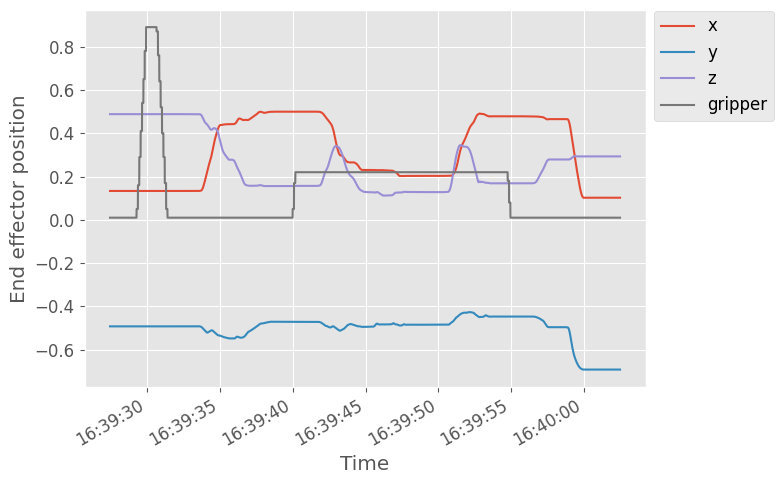

0
1
2
3


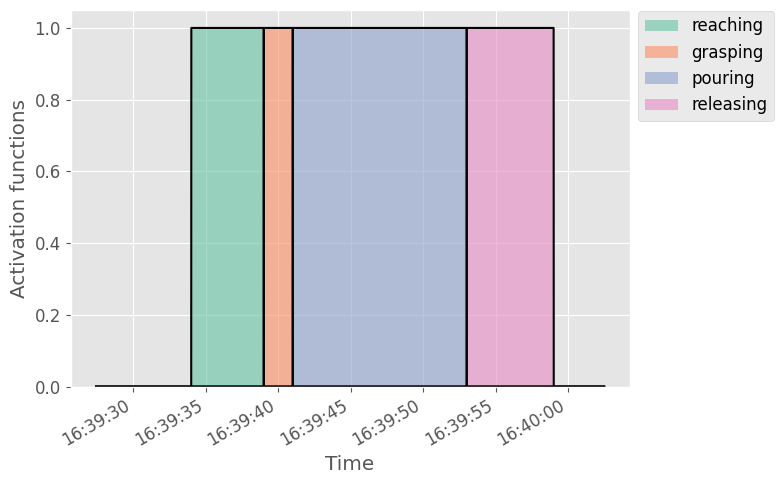

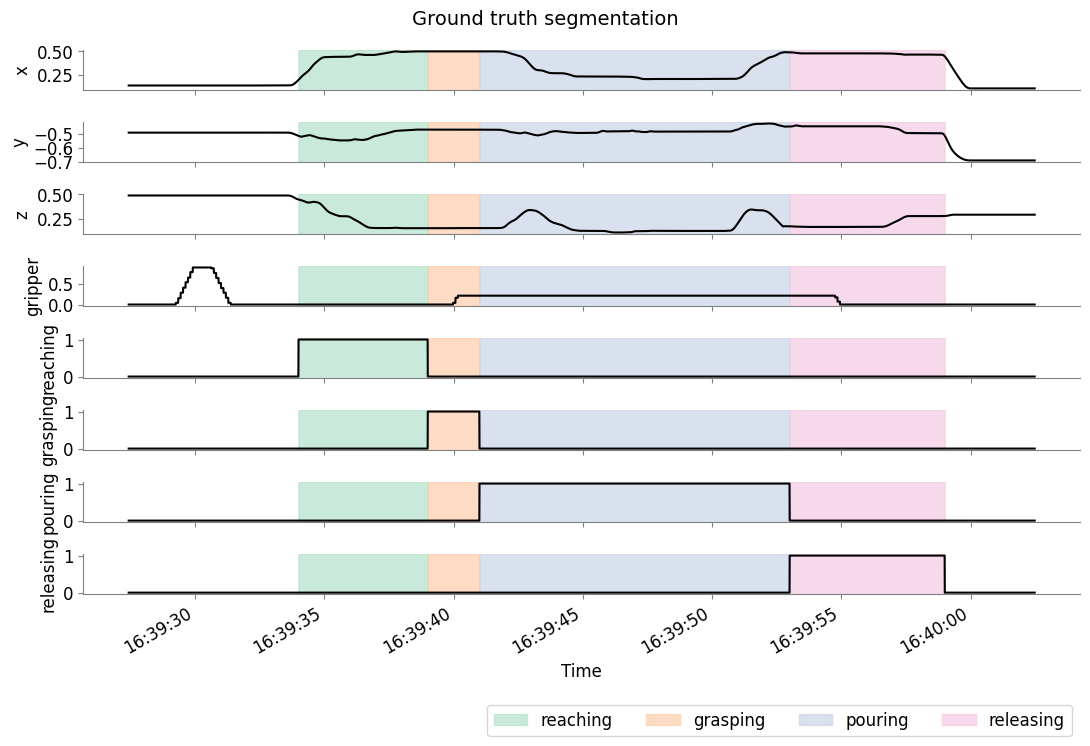

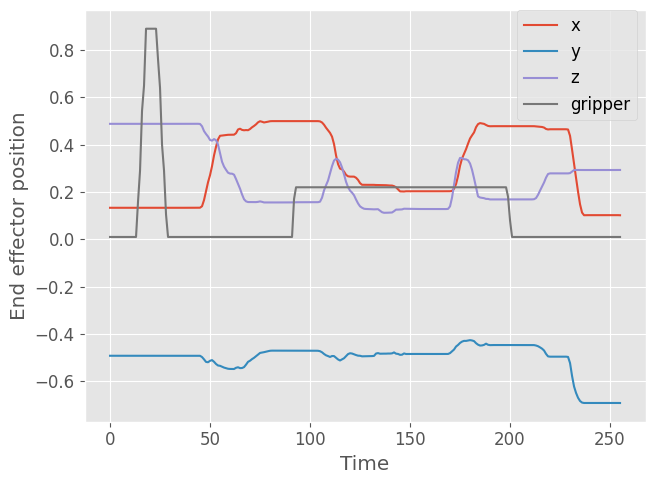

Precision: 1.0 | Recall: 1.0
Hausdorff: 1.0
Rand index: 0.9908394607843137


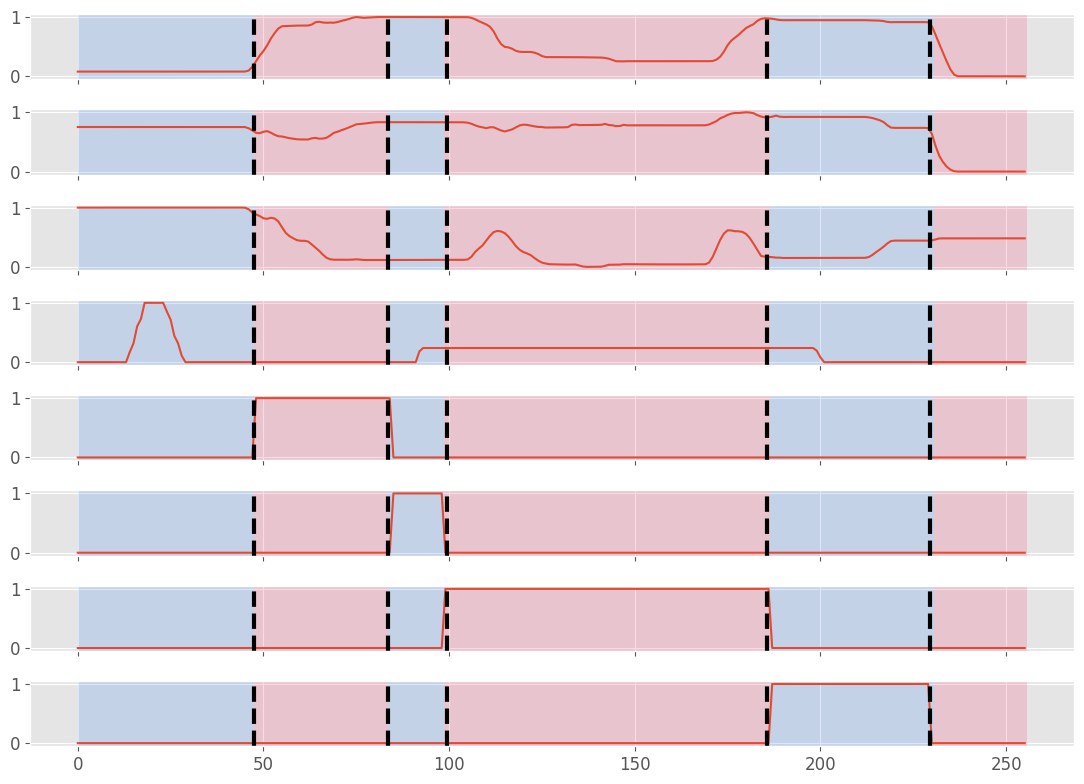

Original shape: (2440, 4) - resampled shape: (256, 4)
Original shape: (1085, 4) - resampled shape: (256, 4)
Original shape: (5830, 4) - resampled shape: (256, 4)
Original shape: (2982, 4) - resampled shape: (256, 4)
Keys in `<HDF5 file "lib.h5" (mode r)>` file:
['Skill_0', 'Skill_1', 'Skill_13', 'Skill_14', 'Skill_17', 'Skill_18', 'Skill_19', 'Skill_2', 'Skill_21', 'Skill_22', 'Skill_23', 'Skill_3', 'Skill_31', 'Skill_4', 'Skill_5', 'Skill_6']
Keys in `<HDF5 group "/Skill_0" (9 members)>` group:
['demo0', 'demo1', 'demo2', 'demo3', 'demo4', 'demo5', 'demo6', 'demo7', 'demo8']
Keys in `<HDF5 group "/Skill_1" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_13" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_14" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_17" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_18" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_19" (2 members)>` group:

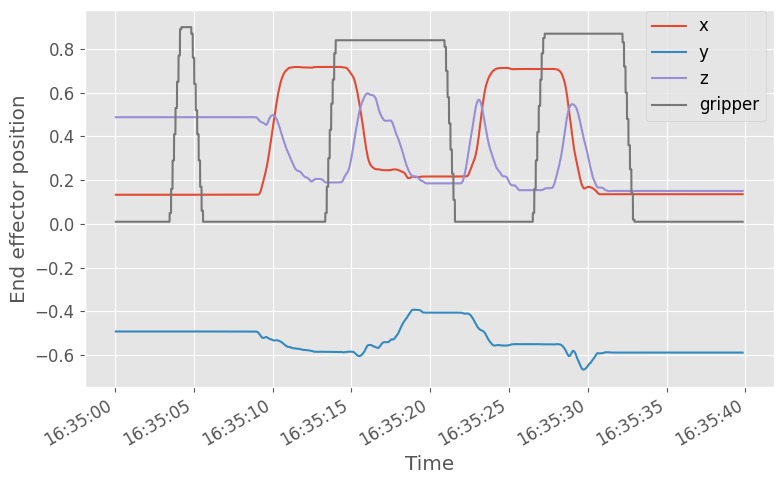

0
1
2
3
4
5
6
7


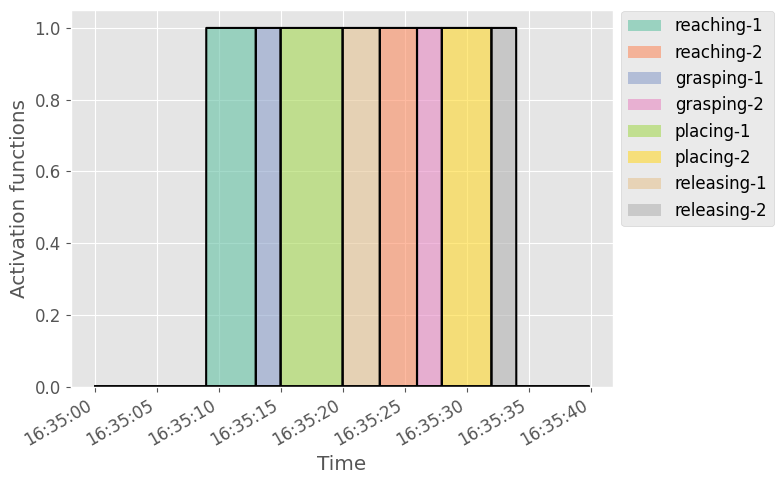

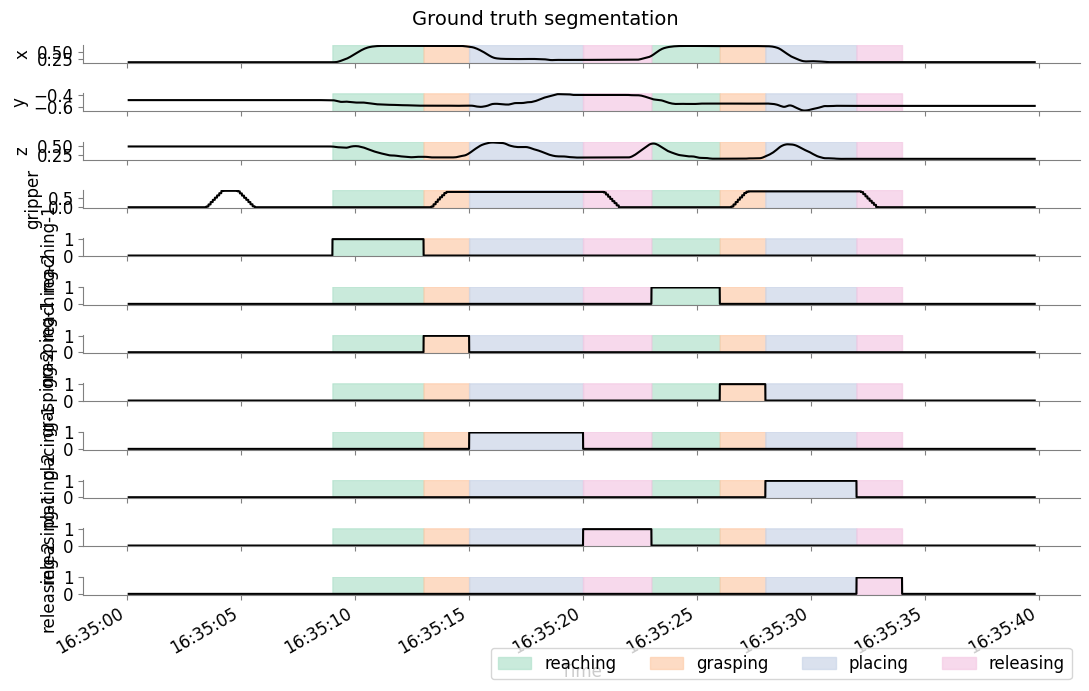

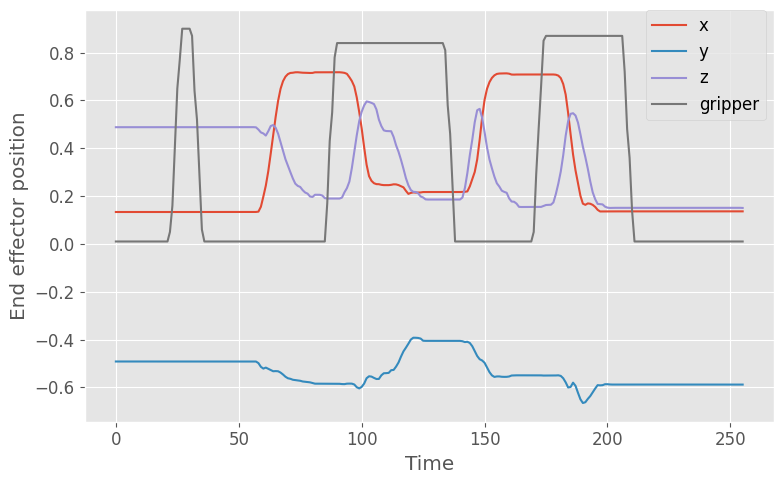

Precision: 1.0 | Recall: 1.0
Hausdorff: 1.0
Rand index: 0.9979166666666667


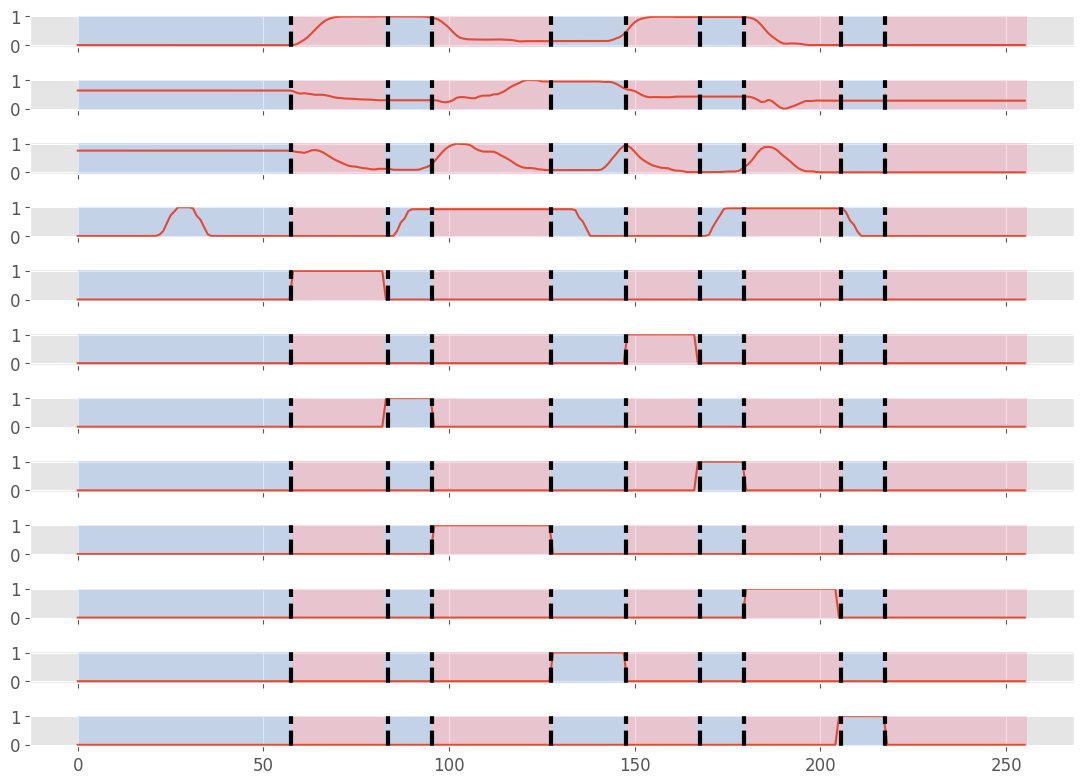

Original shape: (2018, 4) - resampled shape: (256, 4)
Original shape: (931, 4) - resampled shape: (256, 4)
Original shape: (2484, 4) - resampled shape: (256, 4)
Original shape: (1552, 4) - resampled shape: (256, 4)
Original shape: (1553, 4) - resampled shape: (256, 4)
Original shape: (931, 4) - resampled shape: (256, 4)
Original shape: (2018, 4) - resampled shape: (256, 4)
Original shape: (932, 4) - resampled shape: (256, 4)
Keys in `<HDF5 file "lib.h5" (mode r)>` file:
['Skill_0', 'Skill_1', 'Skill_13', 'Skill_14', 'Skill_17', 'Skill_18', 'Skill_19', 'Skill_2', 'Skill_21', 'Skill_22', 'Skill_23', 'Skill_3', 'Skill_31', 'Skill_4', 'Skill_5', 'Skill_6']
Keys in `<HDF5 group "/Skill_0" (10 members)>` group:
['demo0', 'demo1', 'demo2', 'demo3', 'demo4', 'demo5', 'demo6', 'demo7', 'demo8', 'demo9']
Keys in `<HDF5 group "/Skill_1" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_13" (2 members)>` group:
['demo0', 'demo1']
Keys in `<HDF5 group "/Skill_14" (2 members)>` gr

In [18]:
filenums = [2, 4]  # Subtasks
cpd_segm_penalty = 5

for filenum in filenums:
    gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
        ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
    )
    pprint(gt_segm_dict)
    hdf5_path = data_path_root / hdf5_file
    video_path = data_path_root / video_file
    joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)
    traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
    plot_xyzgrip(traj)
    traj, nsegments = augment_traj_activation_functions(
        gt_segm_dict=gt_segm_dict, traj=traj
    )
    plot_segments(traj=traj, gt_segm_dict=gt_segm_dict, nsegments=nsegments)
    # labels = gt_segm_dict["segments"].keys()
    X_down_scaled, X = preprocessing(traj=traj)
    chg_pts_all, true_chg_pts = cpd_segmentation(
        gt_segm_dict=gt_segm_dict,
        traj=traj,
        X=X,
        X_down_scaled=X_down_scaled,
        resample_num=resample_num,
        cpd_segm_penalty=cpd_segm_penalty,
    )
    skills_lib = add2library(
        lib_path=lib_path,
        chg_pts_all=chg_pts_all,
        traj=traj,
        X=X,
        resample_num=resample_num,
        similarity_threshold=similarity_threshold,
    )

In [19]:
# pprint(skills_lib.library)

# Discover skills from long task

{'hdf5': 'long-task-1.h5',
 'segments': {'close-drawer': {'end': 1769723276, 'ini': 1769723270},
              'grasping': [{'end': 1769723226, 'ini': 1769723222},
                           {'end': 1769723239, 'ini': 1769723237},
                           {'end': 1769723253, 'ini': 1769723251},
                           {'end': 1769723270, 'ini': 1769723267},
                           {'end': 1769723296, 'ini': 1769723288}],
              'open-drawer': {'end': 1769723231, 'ini': 1769723226},
              'placing': [{'end': 1769723245, 'ini': 1769723239},
                          {'end': 1769723258, 'ini': 1769723253}],
              'pouring': {'end': 1769723309, 'ini': 1769723296},
              'reaching': [{'end': 1769723222, 'ini': 1769723215},
                           {'end': 1769723237, 'ini': 1769723234},
                           {'end': 1769723251, 'ini': 1769723248},
                           {'end': 1769723267, 'ini': 1769723262},
                           {'end

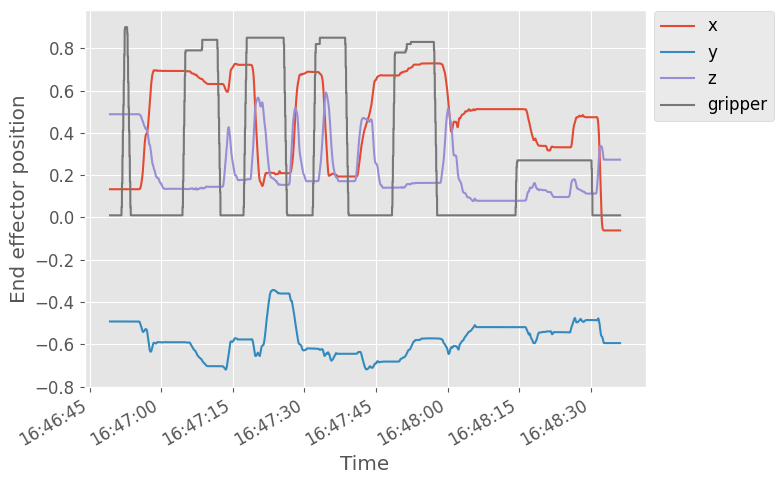

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


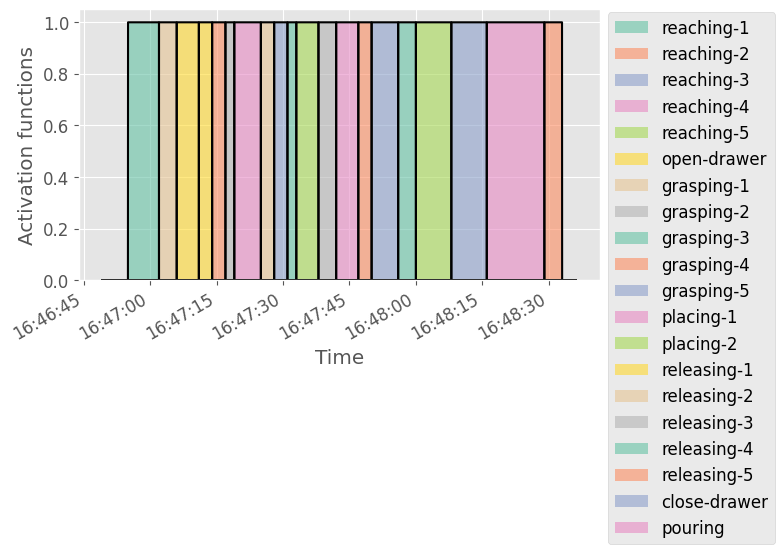

/tmp/ipykernel_3854673/3380954769.py:104: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


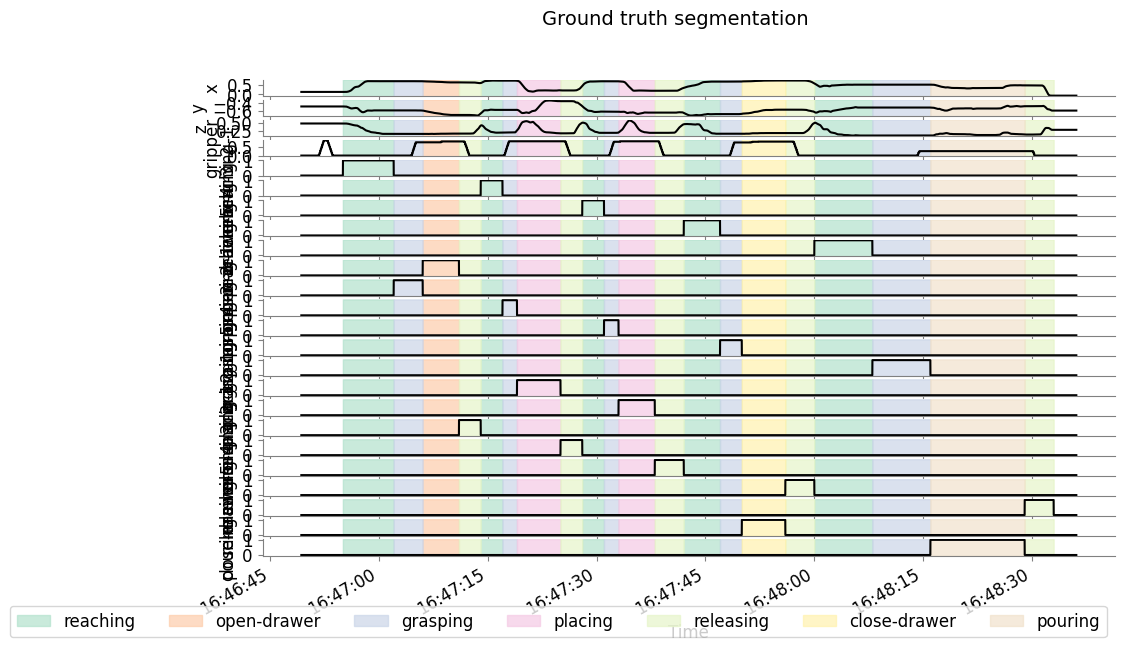

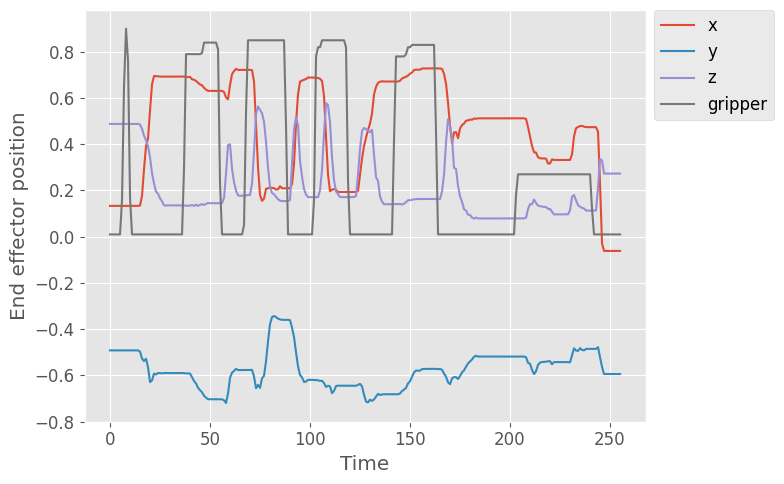

Precision: 0.7142857142857143 | Recall: 0.7142857142857143
Hausdorff: 2.0
Rand index: 0.9915441176470589


/home/kir0ul/Projects/slc/.direnv/python-3.13/lib64/python3.13/site-packages/ruptures/show/display.py:100: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


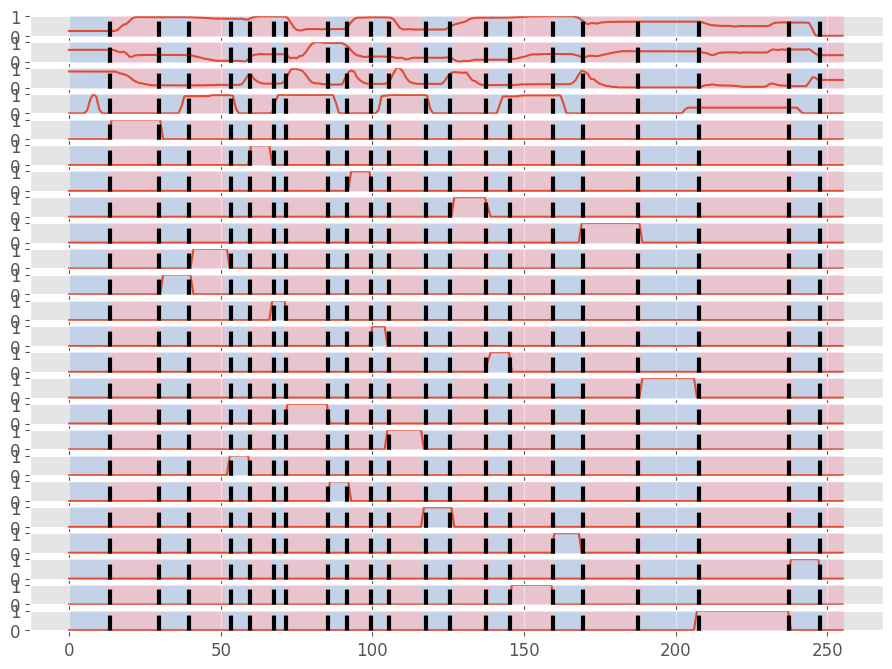

Original shape: (3321, 4) - resampled shape: (256, 4)
Original shape: (2076, 4) - resampled shape: (256, 4)
Original shape: (2906, 4) - resampled shape: (256, 4)
Original shape: (1245, 4) - resampled shape: (256, 4)
Original shape: (1661, 4) - resampled shape: (256, 4)
Original shape: (830, 4) - resampled shape: (256, 4)
Original shape: (2906, 4) - resampled shape: (256, 4)
Original shape: (1245, 4) - resampled shape: (256, 4)
Original shape: (1661, 4) - resampled shape: (256, 4)
Original shape: (1245, 4) - resampled shape: (256, 4)
Original shape: (2491, 4) - resampled shape: (256, 4)
Original shape: (1660, 4) - resampled shape: (256, 4)
Original shape: (2491, 4) - resampled shape: (256, 4)
Original shape: (1661, 4) - resampled shape: (256, 4)
Original shape: (2906, 4) - resampled shape: (256, 4)
Original shape: (2075, 4) - resampled shape: (256, 4)
Original shape: (3736, 4) - resampled shape: (256, 4)
Original shape: (4152, 4) - resampled shape: (256, 4)
Original shape: (6227, 4) - r

In [20]:
filenum = 0  # Long task
cpd_segm_penalty = 2

gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
    ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
)
pprint(gt_segm_dict)
hdf5_path = data_path_root / hdf5_file
video_path = data_path_root / video_file
joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)
traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
plot_xyzgrip(traj)
traj, nsegments = augment_traj_activation_functions(
    gt_segm_dict=gt_segm_dict, traj=traj
)
plot_segments(traj=traj, gt_segm_dict=gt_segm_dict, nsegments=nsegments)
# labels = gt_segm_dict["segments"].keys()
X_down_scaled, X = preprocessing(traj=traj)
chg_pts_all, true_chg_pts = cpd_segmentation(
    gt_segm_dict=gt_segm_dict,
    traj=traj,
    X=X,
    X_down_scaled=X_down_scaled,
    resample_num=resample_num,
    cpd_segm_penalty=cpd_segm_penalty,
)
skills_lib = add2library(
    lib_path=lib_path,
    chg_pts_all=chg_pts_all,
    traj=traj,
    X=X,
    resample_num=resample_num,
    similarity_threshold=similarity_threshold,
)

# Reproduce movements from library & planner (in different order)

In [21]:
# TODO: Export ElMaps files + true_chg_pts in header